### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2025-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

- Pierre Marrec -- `pierre.marrec@inria.fr`

***

### ⚠️ General guidelines for TPs

The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP2: Principal components regression in genetics

The goal of this TP session is to use genetic markers to predict the geographical origin of a set of indians from South, Central, and North America. We propose to build two regression linear models to predict the latitude and longitude of an individual based on its genetic markers. Because the number of markers (p = 5709) is larger than the number of samples (N = 494), the predictors of the regression model will be the outputs of a principal component analysis (PCA) performed on the genetic markers. A genetic marker is encoded 1 if the individual has a mutation, 0 elsewhere.

## ▶️ Exercise 1: Data visualization (1 point)

NB: To do this exercise you will have to install packages `geopandas` and `geodatasets`.

Download dataset `NAm2.txt` from [here](https://github.com/ISLA-Grenoble/2025-main/blob/main/TP/TP2/NAm2.txt). Each row of the dataset corresponds to an individual and the columns have explicit names. The third column contains the names of the tribes to which each individual pertains. Columns 7 and 8 contain the latitude and the longitude and from Column 9 onwards are genetic markers, which are encoded are 0 or 1. Run the code described below and explain how it works.

```
import pandas as pd
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt

# Load the data
file_path = 'NAm2.txt'
df = pd.read_csv(file_path, delimiter=' ')

# Extract relevant columns
latitude = df.iloc[:, 6]
longitude = df.iloc[:, 7]
tribes = df.iloc[:, 2]

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(longitude, latitude))

# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf[gdf['Pop'] == tribe]
    ax.scatter(members_tribe['long'], members_tribe['lat'], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()
```

/tmp/ipykernel_9550/2487305138.py:34: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


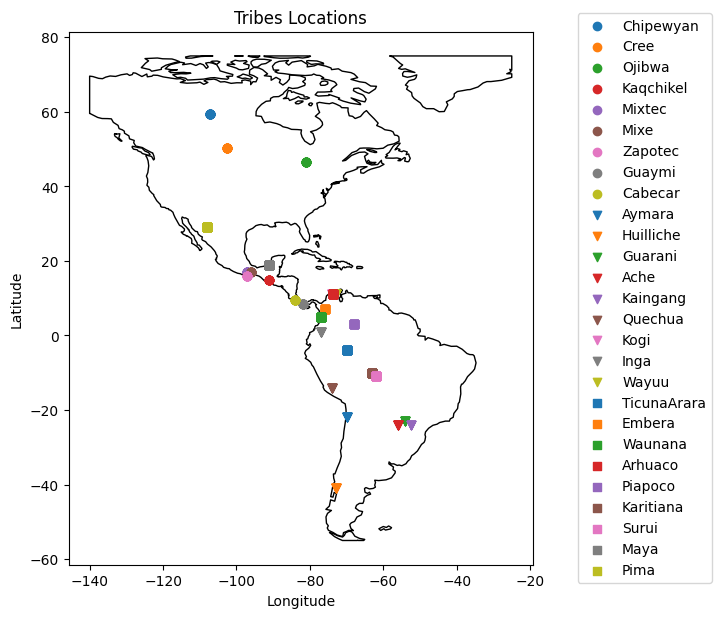

In [1]:
import pandas as pd
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt

# Load the data
file_path = 'NAm2.txt'
df = pd.read_csv(file_path, delimiter=' ')

# Extract relevant columns
latitude = df.iloc[:, 6]
longitude = df.iloc[:, 7]
tribes = df.iloc[:, 2]

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(longitude, latitude))

# Draw a North America map and scatter plot each tribe's locations with different markers/colors
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf[gdf['Pop'] == tribe]
    ax.scatter(members_tribe['long'], members_tribe['lat'], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()

## ▶️ Exercise 2: Multiple linear regression (2 points)

Using **only** the genetic markers as predictors, you will estimate a multiple linear regression model to predict the longitude of each individual.

You will proceed in several steps.

**(a)** First, try to estimate the coefficients of the multiple linear regression using the expression seen in class 

$$\hat{\beta} = (X^\top X)^{-1}X^\top y$$

You should proceed as we did in TP1 using `numpy.linalg.solve` to obtain the values of $\beta$. 

Did you run into any errors? What is going on? Relate your answer to the fact that $\text{rank}(X) < p$, where $X \in R^{N*p}$ is the data matrix.

In [2]:
import numpy as np

predictors = df.columns[8:]
X = df[predictors].values
y = df['long'].values
XtX = X.T @ X
Xty = X.T @ y
beta = np.linalg.solve(XtX, Xty)

print(beta)

LinAlgError: Singular matrix

We get a LinAlgError because $X.T@X$ is not invertible when $rank(X)<p$

**(b)** Use function `numpy.linalg.lstsq` to estimate the coefficients (it may take a few seconds to get a result). 

And now? Did you get any errors? Why is that? 

Relate your answer to the difference between functions `numpy.linalg.solve` and `numpy.linalg.lstsq`.

You can check the documention for both functions as well as [this](https://netlib.org/lapack/lug/node27.html) link for more information.

In [3]:
beta_lstsq, residuals, rank, s = np.linalg.lstsq(X, y, rcond=None)

print(beta_lstsq)

[-0.04005781 -0.01940898  0.01111306 ... -0.21729626 -0.10210421
  0.01813644]


 **(c)** We will now use `sklearn` to do our linear regression with the help of class `sklearn.linear_model.LinearRegression` whose documentation is available [here](https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LinearRegression.html). Note that every estimator from `sklearn` has a `fit` and a `predict` method, which are used to calculate coefficients and predict values (see [here](https://scikit-learn.org/stable/getting_started.html#fitting-and-predicting-estimator-basics) for more info). In our current case, we can do:

```
# select only the genetic markers as predictors
predictors = df.columns[8:]
# create the design matrix
X = df[predictors].values
# get the observed values to predict
y = df['long']
# fit a multiple linear regression model
lr = LinearRegression()
lr.fit(X, y)
```

You should not run into errors now, since `sklearn` also uses `lstsq` to solve the normal equations, as shown [here](https://github.com/scikit-learn/scikit-learn/blob/d666202a9349893c1bd106cc9ee0ff0a807c7cf3/sklearn/linear_model/_base.py#L682) (though it uses the `scipy` implementation instead of the `numpy` for "historical" reasons). Check the values of the estimated coefficients stored as an attribute in `lr.coef_`, are they the same as the ones obtained in item **(b)**? Probably not. This is because `sklearn` re-centers the predictors before estimating the coefficients of the linear regression, as shown [here](https://github.com/scikit-learn/scikit-learn/blob/d666202a9349893c1bd106cc9ee0ff0a807c7cf3/sklearn/linear_model/_base.py#L622). What would be a practical reason for doing such re-centering systematically? Hint: it has to do with how to interpret the intercept of the model. 

In [4]:
from sklearn.linear_model import LinearRegression


predictors = df.columns[8:]
X = df[predictors].values
y = df['long'].values
lr = LinearRegression()
lr.fit(X, y)
print(lr.coef_)

print(lr.intercept_)

[-0.03940988 -0.0245272   0.01089763 ...  0.04804479 -0.08985062
  0.01903025]
-84.01040409306009


Re-centering makes the intercept easier to interpret.

## ▶️ Exercise 3: Principal components analysis (5 points)

**(a)** Explain in a few words the main concepts and ideas underlying the principal component analysis (PCA). You should include both the geometric and statistical interpretations of PCA.

PCA is a way to reduce the dimensionality of a set. It takes a set of possibly correlated variables and turns it into a smaller set of uncorrelated variables.
Geometrically, PCA finds new orthogonal directions in the data that capture the maximum variance, and projects the data onto these directions.
Statistically, the principal components are linear combinations of the original variables obtained from the eigenvectors of the covariance matrix, ordered by the amount of variance they explain.

**(b)** Use the estimator defined in `sklearn.decomposition.PCA` to do a PCA on the dataset. Plot the first two dimensions of the projected data points on a scatterplot. The scattered points should have different markers and colors depending on which tribe they belong to. You can use the same color/marker style from **Exercise 2** or propose a new one.

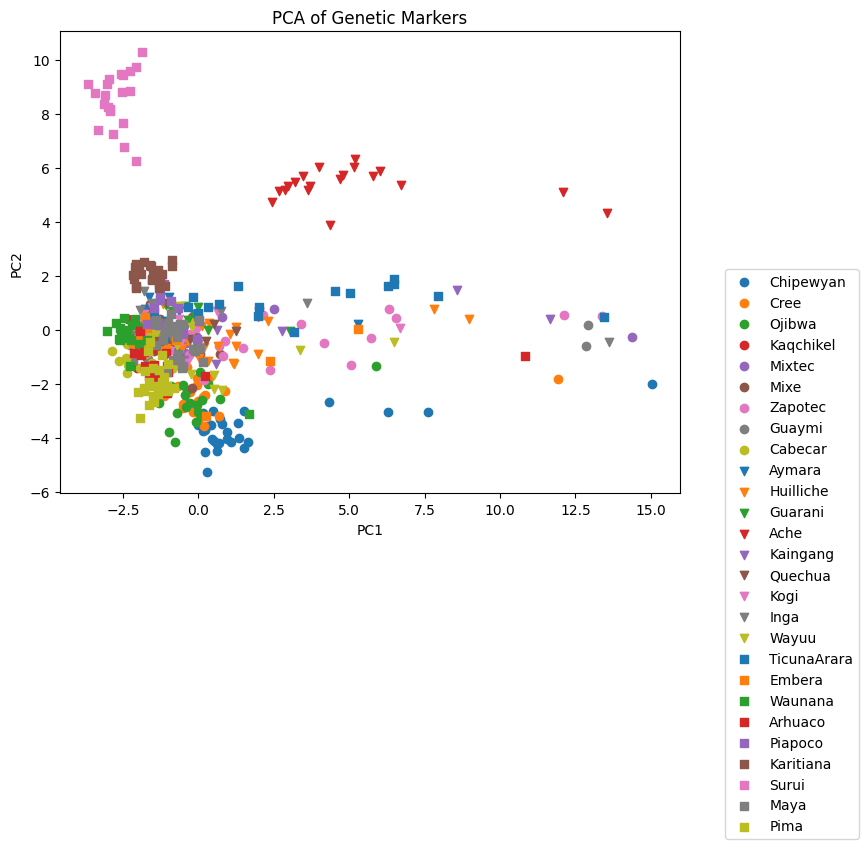

In [5]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

predictors = df.columns[8:]
X = df[predictors].values
tribes = df['Pop']

pca = PCA()
X_pca = pca.fit_transform(X)

marker_list = ['o','v','s']
colors_list = [f'C{i}' for i in range(9)]

plt.figure(figsize=(8,6))

for i, tribe in enumerate(tribes.unique()):
    members = tribes == tribe
    plt.scatter(
        X_pca[members,0],
        X_pca[members,1],
        marker=marker_list[i//9],
        color=colors_list[i%9],
        label=tribe
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Genetic Markers")
plt.legend(bbox_to_anchor=(1.3,0.5))
plt.show()

**(c)** Remember from our class that the results of PCA are affected when pre-processing transformations are applied to the data. We will illustrate this using `sklearn.preprocessing.StandardScaler` as per:
```
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
X_std = scaler.transform(X)
```
Redo the 2D scatter plot from item **(b)** on the normalized version of the datast. How does it compare to your previous plot?

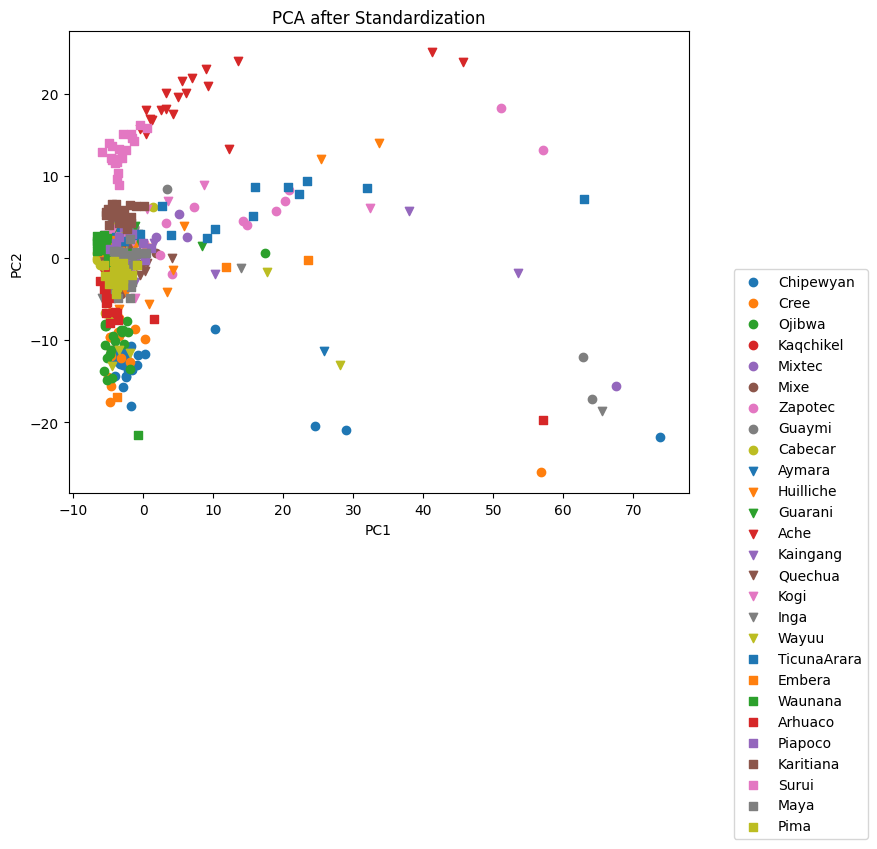

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_std = scaler.fit_transform(X)

pca_std = PCA()
X_pca_std = pca_std.fit_transform(X_std)

plt.figure(figsize=(8,6))

for i, tribe in enumerate(tribes.unique()):
    members = tribes == tribe
    plt.scatter(
        X_pca_std[members,0],
        X_pca_std[members,1],
        marker=marker_list[i//9],
        color=colors_list[i%9],
        label=tribe
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA after Standardization")
plt.legend(bbox_to_anchor=(1.3,0.5))
plt.show()

**(d)** Given the results in **(b)** and **(c)**, what can you conclude regarding the necessity of standardizing the data points for the dataset consider in this TP?

Scaling may not be strictly needed, but it helps ensure that no variables with very large values dominate the results.

**(e)** Which percentage of variance is captured by the first two principal components? How many principal components would you keep if you would like to represent the genetic markers using a minimal number of principal components? To help answering this question, you can use a plot showing the cumulative percentage of variance as a function of the number of principal components.

Variance explained by PC1 and PC2: 0.03568444524213918


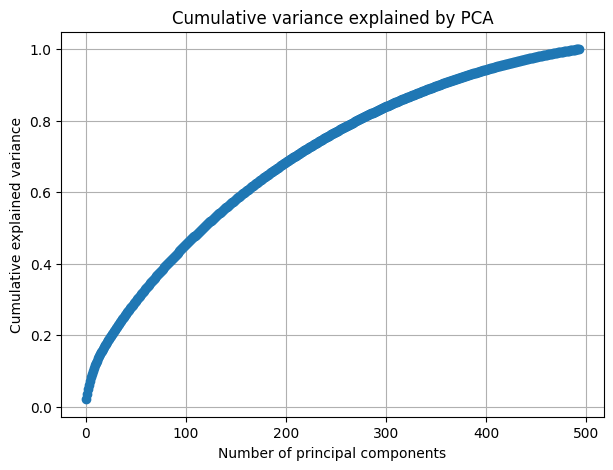

In [7]:
variance = pca.explained_variance_ratio_
print("Variance explained by PC1 and PC2:", variance[:2].sum())
import numpy as np

cum_var = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(7,5))
plt.plot(cum_var, marker='o')
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("Cumulative variance explained by PCA")
plt.grid()
plt.show()

The first two principal components capture only about 3.6% of the total variance, indicating that most variation is spread across many dimensions. To represent the data effectively, hundreds of principal components are needed to capture a high percentage of the variance.

## ▶️ Exercise 4: Principal components regression (4 points)

**(a)** Predict the latitude and the longitude of all points from the dataset using the scores of the first 250 PCA axes. Plot the predicted spatial coordinates using the same style and structure from **Exercise 1** and compare the results from each plot. What can you conclude? Does the new map illustrate somehow too optimistically (or too pessimistically) the ability to find geographical origin of individuals outside the database from its genetic markers? Justify your answer.

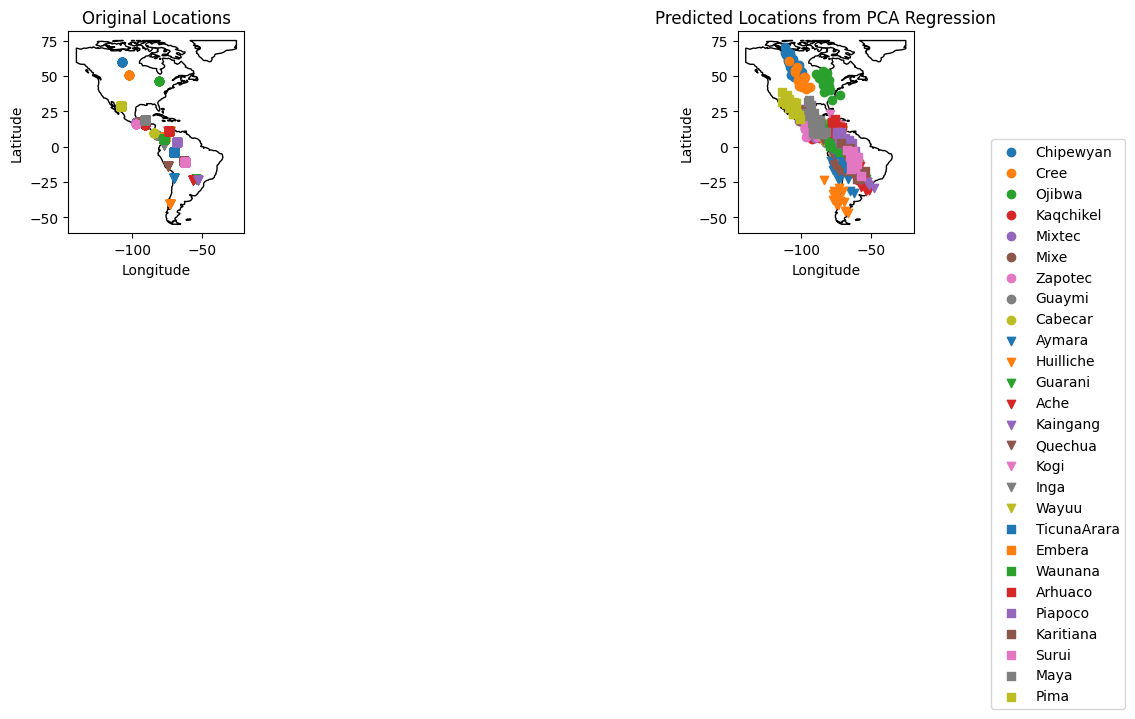

In [8]:
from sklearn.linear_model import LinearRegression
import numpy as np

n_components = 250

pca_250 = PCA(n_components=n_components)
X_pca_250 = pca_250.fit_transform(X)

lr_lat = LinearRegression().fit(X_pca_250, df['lat'])
lr_long = LinearRegression().fit(X_pca_250, df['long'])

lat_pred = lr_lat.predict(X_pca_250)
long_pred = lr_long.predict(X_pca_250)


fig, axs = plt.subplots(1, 2, figsize=(15, 6))

world.clip([-140, -55, -25, 75]).plot(ax=axs[0], color='white', edgecolor='black')
for i, tribe in enumerate(df['Pop'].unique()):
    members = df['Pop'] == tribe
    axs[0].scatter(df.loc[members, 'long'], df.loc[members, 'lat'],
                   marker=marker_list[i//9], color=colors_list[i%9], label=tribe)
axs[0].set_title("Original Locations")
axs[0].set_xlabel("Longitude")
axs[0].set_ylabel("Latitude")

world.clip([-140, -55, -25, 75]).plot(ax=axs[1], color='white', edgecolor='black')
for i, tribe in enumerate(df['Pop'].unique()):
    members = df['Pop'] == tribe
    axs[1].scatter(long_pred[members], lat_pred[members],
                   marker=marker_list[i//9], color=colors_list[i%9], label=tribe)
axs[1].set_title("Predicted Locations from PCA Regression")
axs[1].set_xlabel("Longitude")
axs[1].set_ylabel("Latitude")

plt.legend(bbox_to_anchor=(1.4, 0.5))
plt.tight_layout()
plt.show()

The predicted map looks smoother and simpler than the real one. It might seem better than it really is because the model fits the data it knows but may not work well for new people not in the dataset.

**(b)** Quantify the error of the linear regression model using the mean distance between real and predicted coordinates. Beware to use `sklearn.metrics.pairwise.haversine_distances` so to correctly measure the distances between points so to take into account the curvature of the Earth. Your answer should be given in kilometers.

In [9]:
from sklearn.metrics.pairwise import haversine_distances

y_true_rad = np.radians(df[['lat', 'long']].values)        
y_pred_rad = np.radians(np.column_stack((lat_pred, long_pred))) 
dist_matrix = haversine_distances(y_true_rad, y_pred_rad)
dist_rad = np.diag(dist_matrix)

earth_radius_km = 6371.0
dist_km = dist_rad * earth_radius_km

mean_error_km = np.mean(dist_km)
print(f"Mean prediction error: {mean_error_km:.2f} km")

Mean prediction error: 627.84 km


## ▶️ Exercise 5: PCR and cross-validation (6 points)

Our goal now is to build the best model to predict individual geographical coordinates. 

For this, you will run a linear regression to predict latitudes and longitudes. Note that `sklearn.linear_model.LinearRegression` can naturally handle the fact of having two sets of coefficients. We will use ten-fold cross-validation to helps us choose the number of principal axes that we should keep. You should report the errors in terms of kilometers as done in **Exercise 4(b)**.

**(a)** Recall in a few words the principle of cross-validation. Explain why this procedure is useful when building a predictive model. Your answer should mention different strategies to handle datasets in which the samples are not IID.

Cross-validation splits the data into training and test sets many times to see how well the model works on new data. It helps avoid overfitting and shows if the model can generalize.

**(b)** Based on the structure of the dataset being used, such as the different countries of the individuals and the order in which the rows of the dataframe are provided, explain which choice of cross-validation iterator from [here](https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation-iterators) seems the most adequate for our context.

Since people from the same country/tribe are similar, we should keep all from the same group together in each fold, so the test set is realistic.

**(c)** We first assess the quality of the PCR fit for `n_components=4`. Note that you should be careful in avoiding [data leakage](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage) problems when doing the PCA followed by a multiple linear regression. You should use the pipeline interface from scikit-learn with `sklearn.pipeline.make_pipeline` to facilitate your task. Be sure to evaluate the errors as done in **Exercise 4(b)**.

In [10]:
from sklearn.model_selection import KFold
from sklearn.pipeline import make_pipeline
from sklearn.metrics.pairwise import haversine_distances
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
import numpy as np


X = df[predictors].values
y_coords = df[['lat', 'long']].values

n_components = 4
pipeline = make_pipeline(PCA(n_components=n_components), LinearRegression())

kf = KFold(n_splits=10, shuffle=True, random_state=42)
errors_km = []

for train_idx, test_idx in kf.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y_coords[train_idx], y_coords[test_idx]
 
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    dist_matrix = haversine_distances(np.radians(y_test), np.radians(y_pred))
    dist_km = np.diag(dist_matrix) * 6371
    errors_km.append(np.mean(dist_km))

print(f"Mean CV error with {n_components} PCs: {np.mean(errors_km):.2f} km")

Mean CV error with 4 PCs: 1878.62 km


**(d)** Repeat the analysis from item **(b)** but changing `n_components` between 2 and 440 in steps of 10. Plot the mean training and test errors versus the number of principal components. Attention, the errors should be given in kilometers.

**(e)** Which model would you keep? What is the prediction error for this model? Compare it with its corresponding training error. Plot the predicted coordinates on a map as in **Exercise 4(a)**. What can you conclude?

## ▶️ Exercise 6: Conclusion (2 points)

Propose a conclusion to your study. You can write a paragraph about the quality of predictors versus the number of factors, possible improvements to the approach (for instance, showing what happens when using [partial least squares](https://scikit-learn.org/1.5/auto_examples/cross_decomposition/plot_pcr_vs_pls.html) instead of PCR), comment on the performance of the regression in predictions for each country separately, etc. Note that we expect a thorough presentation of the final predictive model as well as an interpretation of it, not simply a bunch of `python` code lines.